In [ ]:
import pandas as pd 

df_mortalidad = pd.read_parquet("mortalidad_limpio.parquet")

C:\Users\Eliel David\AppData\Local\Temp\ipykernel_2476\1999618278.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


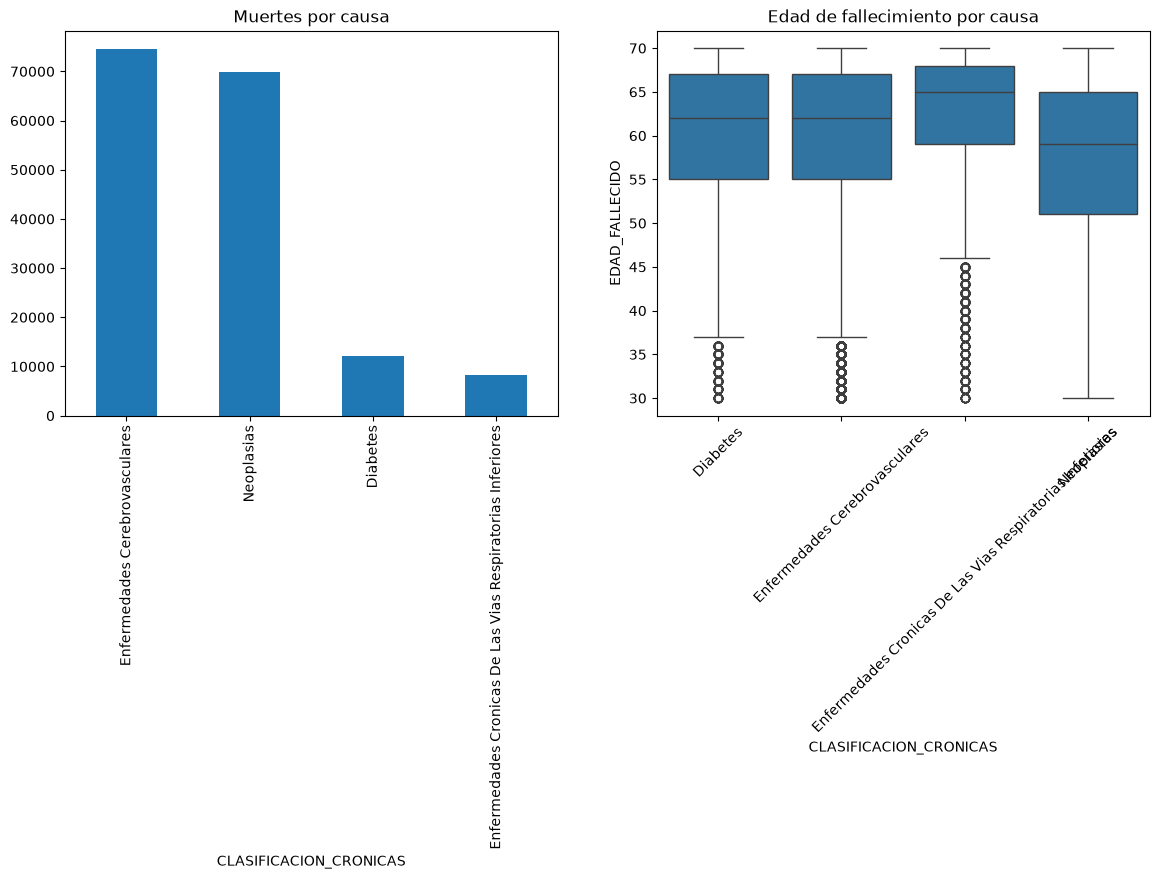

Outliers detectados: 4088
Rango normal: 36.0 a 84.0 años


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución por causa
df_mortalidad['CLASIFICACION_CRONICAS'].value_counts().plot(kind='bar', ax=axes[0], title='Muertes por causa')

# Box plot edad por causa
sns.boxplot(data=df_mortalidad, x='CLASIFICACION_CRONICAS', y='EDAD_FALLECIDO', ax=axes[1])
axes[1].set_title('Edad de fallecimiento por causa')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('distribucion_causas.png', dpi=150)
plt.show()

# Outliers IQR en edad
Q1 = df_mortalidad['EDAD_FALLECIDO'].quantile(0.25)
Q3 = df_mortalidad['EDAD_FALLECIDO'].quantile(0.75)
IQR = Q3 - Q1
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR
outliers = df_mortalidad[(df_mortalidad['EDAD_FALLECIDO'] < limite_inf) | (df_mortalidad['EDAD_FALLECIDO'] > limite_sup)]
axes[1].tick_params(axis='x', rotation=90)
print(f"Outliers detectados: {len(outliers)}")
print(f"Rango normal: {limite_inf:.1f} a {limite_sup:.1f} años")